In [141]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Any, Annotated, Literal
import operator
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

In [142]:
"""
Task: One llm should create a tweet and send it to another llm for evaluation.
 If the tweet is not good enough, the second llm should send it back to the first llm for improvement. 
 This process should continue until the tweet is good enough.

"""

'\nTask: One llm should create a tweet and send it to another llm for evaluation.\n If the tweet is not good enough, the second llm should send it back to the first llm for improvement. \n This process should continue until the tweet is good enough.\n\n'

In [143]:
_tweetGeneratorChatModel = ChatOpenAI(model_name="gpt-4o", temperature=0.7, max_tokens=300)
_tweetEvaluatorChatModel = ChatOpenAI(model_name="gpt-4o", temperature=0.7, max_tokens=300)

In [144]:
class EvaluationResult(BaseModel):
    rating: int = Field(..., le=5, ge=1, description="Quality of the tweet on a 1-5 scale, where 5 is excellent.")
    feedback: str = Field(..., description="Concrete, actionable feedback on how to improve the tweet.")

class Tweet(BaseModel):
    content: str = Field(..., description="The content of the tweet.")


In [145]:
tweetEvaluatorChatModel = _tweetEvaluatorChatModel.with_structured_output(EvaluationResult)
tweetGeneratorChatModel = _tweetGeneratorChatModel.with_structured_output(Tweet)

In [146]:
prompt1 = "generate a tweet about {topic}"

prompt2 = (
    "evaluate the following tweet: {content}. "
    "Rate it from 1 to 5 and provide feedback for improvement."
)

# used on every retry, so the generator can actually act on the critique
prompt3 = (
    "generate an improved tweet about {topic}.\n"
    "Previous attempt: {content}\n"
    "Feedback to address: {feedback}"
)

In [147]:
class TweetState(TypedDict):
    topic: str
    content: str
    retry_count: int
    max_retries: int
    final_tweet: str
    rating: int
    generated_tweets: Annotated[list[str], operator.add]
    feedback: Annotated[list[str], operator.add]

In [148]:
PASSING_RATING = 4


def create_tweet(state: TweetState):
    feedback = state.get("feedback", [])

    if feedback:
        # retry: rewrite the last attempt using the newest critique
        prompt = prompt3.format(
            topic=state["topic"],
            content=state["content"],
            feedback=feedback[-1],
        )
    else:
        prompt = prompt1.format(topic=state["topic"])

    response = tweetGeneratorChatModel.invoke(prompt)

    # return only the delta -- the operator.add reducer appends for us
    return {"content": response.content, "generated_tweets": [response.content]}


def evaluate_tweet(state: TweetState):
    response = tweetEvaluatorChatModel.invoke(prompt2.format(content=state["content"]))

    # always keep the latest tweet as the result, so final_tweet is populated
    # even when we stop because retries ran out
    update = {"rating": response.rating, "final_tweet": state["content"]}

    if response.rating < PASSING_RATING:
        update["feedback"] = [response.feedback]
        update["retry_count"] = state["retry_count"] + 1

    return update


def route(state: TweetState) -> Literal["approved", "retry"]:
    if state["rating"] >= PASSING_RATING or state["retry_count"] >= state["max_retries"]:
        return "approved"
    return "retry"


In [149]:
graph = StateGraph(TweetState)

In [150]:
graph.add_node("create_tweet", create_tweet)
graph.add_node("evaluate_tweet", evaluate_tweet)

graph.add_edge(START, 'create_tweet')
graph.add_edge('create_tweet', 'evaluate_tweet')
graph.add_conditional_edges('evaluate_tweet', route, {"approved": END, "retry": "create_tweet"})

In [151]:
final = graph.compile()

In [153]:
result = final.invoke({
    "topic": "Artificial Intelligence",
    "content": "",
    "retry_count": 0,
    "max_retries": 3,
    "final_tweet": "",
    "rating": 0,
    "generated_tweets": [],
    "feedback": [],
})

print("final tweet:", result["final_tweet"])
print("rating:", result["rating"], "| attempts:", len(result["generated_tweets"]))
result

final tweet: 🤖🌟 AI isn't just a buzzword—it's shaping our future! From healthcare to entertainment, AI is revolutionizing industries, sparking innovation, and creating endless possibilities. Let's embrace the tech, but always keep ethics and humanity at the core. #AI #Innovation
rating: 4 | attempts: 1


{'topic': 'Artificial Intelligence',
 'content': "🤖🌟 AI isn't just a buzzword—it's shaping our future! From healthcare to entertainment, AI is revolutionizing industries, sparking innovation, and creating endless possibilities. Let's embrace the tech, but always keep ethics and humanity at the core. #AI #Innovation",
 'retry_count': 0,
 'max_retries': 3,
 'final_tweet': "🤖🌟 AI isn't just a buzzword—it's shaping our future! From healthcare to entertainment, AI is revolutionizing industries, sparking innovation, and creating endless possibilities. Let's embrace the tech, but always keep ethics and humanity at the core. #AI #Innovation",
 'rating': 4,
 'generated_tweets': ["🤖🌟 AI isn't just a buzzword—it's shaping our future! From healthcare to entertainment, AI is revolutionizing industries, sparking innovation, and creating endless possibilities. Let's embrace the tech, but always keep ethics and humanity at the core. #AI #Innovation"],
 'feedback': []}

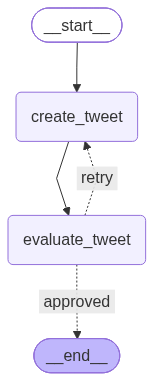

In [157]:
final